In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
#下面的函数为本章你需要学习的内容
def numerical_derivative(f, x):
    h=1e-5
    return (f(x+h)-f(x-h)) / (2*h)


def f(x):
    return 0.01*x**2 + 0.1*x

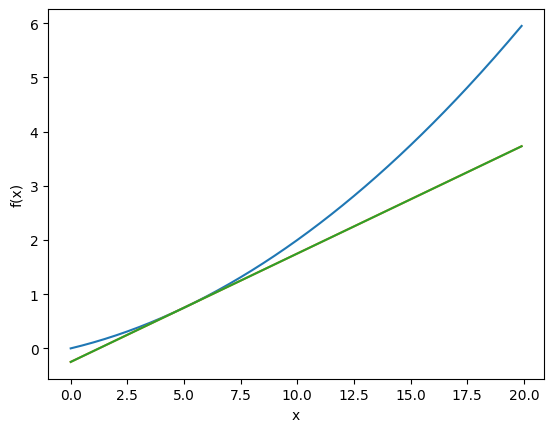

In [13]:
x=np.arange(0.0,20.0,0.1)
y = f(x)
# 计算的斜率
y_numerical_derivative_c = numerical_derivative(f, 5.0)
# 实际斜率
y_numerical_derivative = 0.02*5.0 + 0.1
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")

plt.plot(x, y_numerical_derivative_c*(x-5)+f(5))
plt.plot(x, y_numerical_derivative*(x-5)+f(5))
plt.show()

你可以自己选择合适的h值，你可以发现，一般来说，h值小点，可能更精准，但是计算机表示的的精度有所限制，如果太小可能表示不出,我们采用手算倒数与numerical_derivative(f, x)函数帮我我们计算，发现大致是重合的，说明对这个函数还是比较准的。

In [ ]:
def f1(x):
    return np.sum(x**2, axis=0)

# 此出x可以是矩阵，但是必须按照列进行微分,最好还是单独用一行
def numerical_gradient(f, x):
    h=1e-5
    grad = np.zeros(x.shape)
    for i in range(x.shape[0]):
        x[i] += h
        f_1 = f1(x)
        x[i] -= 2*h
        f_2 = f1(x)
        grad[i] = (f_1 - f_2) / (2*h)
        x[i] += h
    return grad

In [39]:
# test
x=np.array([[3.0, 4.0],
            [0.0, 2.0],
            [3.0,0.0]])
x=x.T
print(f1(x))
print(numerical_gradient(f1, x).T)


[25.  4.  9.]
[[6. 8.]
 [0. 4.]
 [6. 0.]]


In [43]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x.T
    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x.T

In [44]:
# test
init_x = np.array([-3.0, 4.0])
print(gradient_descent(f1, init_x=init_x, lr=0.1, step_num=100))

[-6.11110793e-10  8.14814391e-10]
